# Centralidades de Katz y Pagerank

Son los personajes de Star Wars: Episode II - Attack of the Clones, conectados si comparten escenas; las aristas tienen pesos igual a la cantidad de escenas que comparten.

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from pathlib import Path

plt.set_cmap("rainbow")

<Figure size 640x480 with 0 Axes>

In [2]:
folder = Path("data/dataverse/gexf")
movie_id = 774
fp = folder / f"{movie_id}.gexf"

G = nx.read_gexf(fp, node_type=int)
print("loaded", movie_id, "| Nodos:", G.number_of_nodes(),
      "| Aristas:", G.number_of_edges())

loaded 774 | Nodos: 47 | Aristas: 148


In [3]:
def relabel_nodes_from_attr(
    G: nx.Graph,
    *,
    attr: str = "label",
    fallback_to_id: bool = True,
    make_unique: bool = True,
    copy: bool = True,
) -> nx.Graph:
    """
    Renombra nodos usando G.nodes[n][attr] (p.ej. 'label').
    - make_unique=True agrega sufijos ' (#2)' si hay nombres repetidos.
    """
    base_names = {}
    for n, d in G.nodes(data=True):
        name = d.get(attr)
        if name in (None, "") and fallback_to_id:
            name = str(n)
        base_names[n] = str(name)

    if make_unique:
        counts = {}
        mapping = {}
        for n, nm in base_names.items():
            k = counts.get(nm, 0) + 1
            counts[nm] = k
            mapping[n] = nm if k == 1 else f"{nm} (#{k})"
    else:
        mapping = base_names

    return nx.relabel_nodes(G, mapping, copy=copy)


G1 = relabel_nodes_from_attr(G, attr="label", make_unique=True, copy=True)

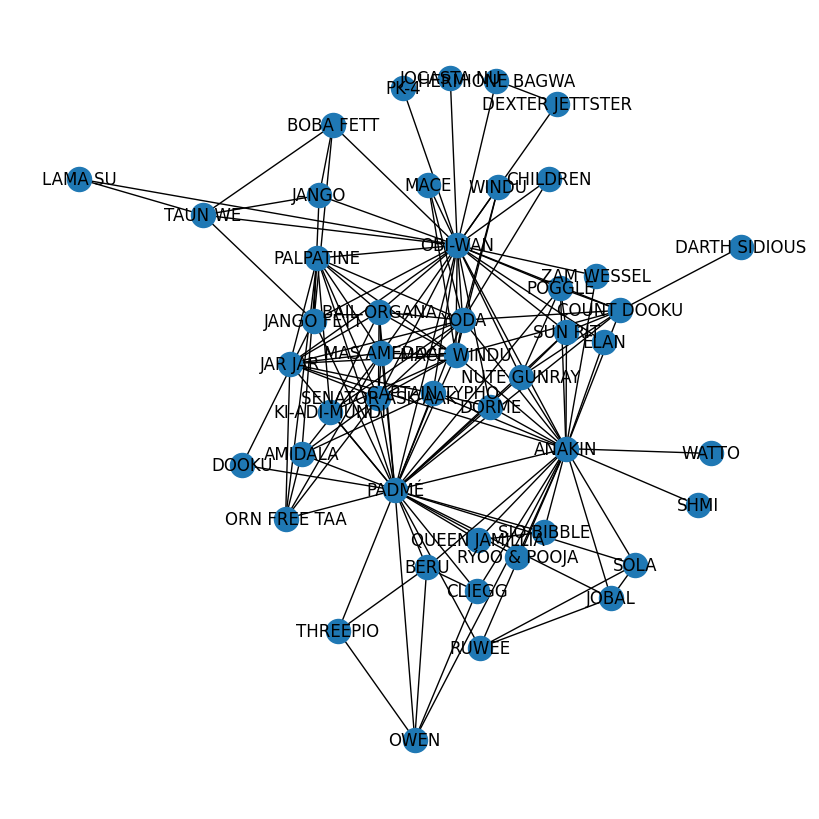

In [4]:
plt.figure(figsize=[8, 8])
layout = nx.kamada_kawai_layout(G1)
nx.draw(G1, layout, with_labels=True)

# Actividad

 ¿qué se puede decir de los vértices de mayor centralidad? ¿Tiene sentido? ¿Qué se puede decir de la centralidad de sus vecinos? ¿En qué cambian? ¿Cómo se comparan con los vértices obtenidos en la actividad de centralidad de grado y de eigenvector? Para los vértices que bajan o suben de centralidad, ¿qué se puede decir de sus vecinos?




In [5]:
def safe_katz_centrality(G, alpha=0.5, step=0.01):
    while alpha > 0:
        try:
            return nx.katz_centrality(G, alpha=alpha), alpha
        except Exception:
            alpha -= step

    raise ValueError("Katz centrality did not converge for any positive alpha.")

deg_centralidades = nx.degree_centrality(G1)
eig_centralidades = nx.eigenvector_centrality(G1)
katz_centralidades, katz_alpha = safe_katz_centrality(G1, alpha=0.09)
print(f"Convergio con un alpha={katz_alpha:.4f}")
pg_centralidades = nx.pagerank(G1)


def sum1_dict(d):
    s = sum(d.values())
    return {k: (v / s if s != 0 else 0.0) for k, v in d.items()}


deg_centralidades = sum1_dict(deg_centralidades)
eig_centralidades = sum1_dict(eig_centralidades)
katz_centralidades = sum1_dict(katz_centralidades)
pg_centralidades = sum1_dict(pg_centralidades)


eig_sizes = np.array([eig_centralidades[n] for n in G1])
deg_colors = np.array([deg_centralidades[i] for i in G1])
pg_sizes = np.array([pg_centralidades[n] for n in G1])
katz_colors = np.array([katz_centralidades[i] for i in G1])


Convergio con un alpha=0.0800


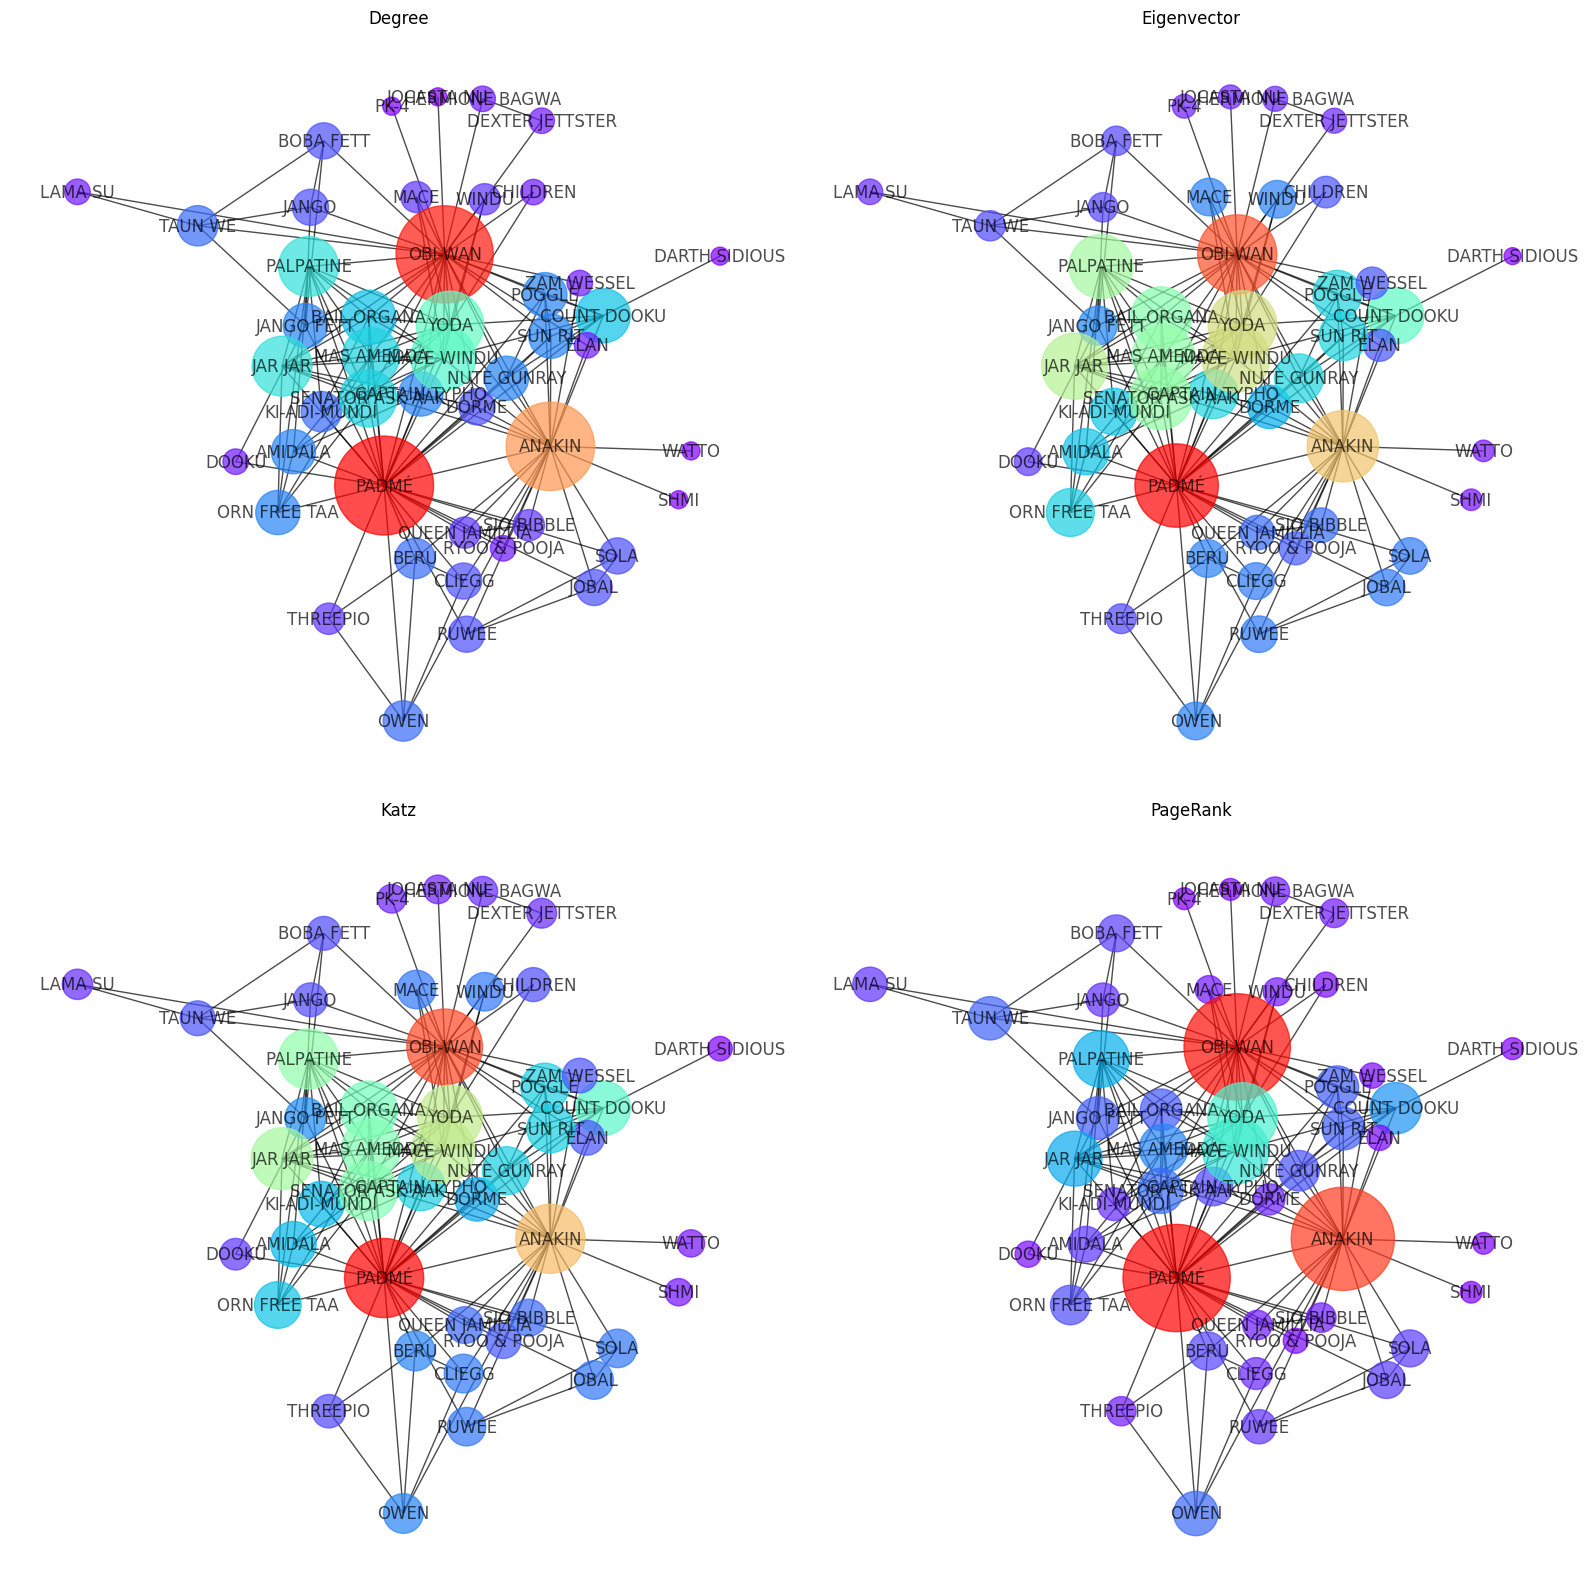

In [6]:
plt.figure(figsize=(16, 16))

nsize = 50000

plt.subplot(2, 2, 1)
nx.draw_kamada_kawai(G1, node_size=nsize*deg_colors,
                     node_color=deg_colors, with_labels=True, alpha=0.7)
plt.title("Degree")

plt.subplot(2, 2, 2)
nx.draw_kamada_kawai(G1, node_size=nsize*eig_sizes,
                     node_color=eig_sizes, with_labels=True, alpha=0.7)
plt.title("Eigenvector")

plt.subplot(2, 2, 3)
nx.draw_kamada_kawai(G1, node_size=nsize*katz_colors,
                     node_color=katz_colors, with_labels=True, alpha=0.7)
plt.title("Katz")

plt.subplot(2, 2, 4)
nx.draw_kamada_kawai(G1, node_size=nsize*pg_sizes,
                     node_color=pg_sizes, with_labels=True, alpha=0.7)
plt.title("PageRank")

plt.tight_layout()
plt.show()

## Funciones

In [7]:
k = 10

top_deg = [n for n, v in sorted(
    deg_centralidades.items(), key=lambda kv: kv[1], reverse=True)[:k]]
top_eig = [n for n, v in sorted(
    eig_centralidades.items(), key=lambda kv: kv[1], reverse=True)[:k]]
top_katz = [n for n, v in sorted(
    katz_centralidades.items(), key=lambda kv: kv[1], reverse=True)[:k]]
top_pg = [n for n, v in sorted(
    pg_centralidades.items(), key=lambda kv: kv[1], reverse=True)[:k]]

In [8]:
# plot centralidades

def plot_centralidades(top_pos, title: str = '', nodesize=10000):
    top_pos_eig = np.array([eig_centralidades[n] for n in top_pos])
    top_pos_deg = np.array([deg_centralidades[n] for n in top_pos])
    top_pos_katz = np.array([katz_centralidades[n] for n in top_pos])
    top_pos_pg = np.array([pg_centralidades[n] for n in top_pos])

    plt.figure(figsize=(16, 16))
    pos = nx.kamada_kawai_layout(G1)

    plt.subplot(2, 2, 2)
    nx.draw_networkx_edges(G1, pos, alpha=0.15, width=1.0)
    nx.draw_networkx_nodes(G1, pos, nodelist=top_pos, node_size=nodesize*top_pos_eig,
                           node_color=top_pos_eig, alpha=0.6)
    nx.draw_networkx_labels(
        G1, pos, labels={n: n for n in top_pos}, font_size=10)
    plt.title("Eigenvector")
    plt.axis("off")

    plt.subplot(2, 2, 1)
    nx.draw_networkx_edges(G1, pos, alpha=0.15, width=1.0)
    nx.draw_networkx_nodes(G1, pos, nodelist=top_pos, node_size=nodesize*top_pos_deg,
                           node_color=top_pos_deg, alpha=0.6)
    nx.draw_networkx_labels(
        G1, pos, labels={n: n for n in top_pos}, font_size=10)
    plt.title("Degree")
    plt.axis("off")

    plt.subplot(2, 2, 3)
    nx.draw_networkx_edges(G1, pos, alpha=0.15, width=1.0)
    nx.draw_networkx_nodes(G1, pos, nodelist=top_pos, node_size=nodesize*top_pos_katz,
                           node_color=top_pos_katz, alpha=0.6)
    nx.draw_networkx_labels(
        G1, pos, labels={n: n for n in top_pos}, font_size=10)
    plt.title("Katz")
    plt.axis("off")

    plt.subplot(2, 2, 4)
    nx.draw_networkx_edges(G1, pos, alpha=0.15, width=1.0)
    nx.draw_networkx_nodes(G1, pos, nodelist=top_pos, node_size=nodesize*top_pos_pg,
                           node_color=top_pos_pg, alpha=0.6)
    nx.draw_networkx_labels(
        G1, pos, labels={n: n for n in top_pos}, font_size=10)
    plt.title("PageRank")
    plt.axis("off")

    plt.suptitle(title, fontsize=20)
    plt.tight_layout()
    plt.show()

In [9]:
# tabla

def tabla(top_pos, digits):
    df = (
        pd.DataFrame({
            "node": top_pos,
            "Degree": [deg_centralidades[n] for n in top_pos],
            "Eigenvector": [eig_centralidades[n] for n in top_pos],
            "Katz": [katz_centralidades[n] for n in top_pos],
            "PageRank": [pg_centralidades[n] for n in top_pos],
        })
        .reset_index(drop=True)
    )


    display(
        df.style.format(
            {
                "Eigenvector": f"{{:.{digits}f}}",
                "Degree": f"{{:.{digits}f}}",
                "PageRank": f"{{:.{digits}f}}",
                "Katz": f"{{:.{digits}f}}",
            }
        )
    )
    return df

In [10]:
# vecinos

import matplotlib


def ego_layers(G, center, max_radius):
    layers = []
    prev = set()
    for r in range(0, max_radius + 1):
        nodes_r = set(nx.ego_graph(G, center, radius=r).nodes())
        layers.append(nodes_r - prev)  # exactly distance r
        prev = nodes_r
    return layers  # [L0, L1, ..., Lmax]


def layer_color_map(layers, cmap_name="Reds", stops=None, default="lightgray"):
    # stops: list of floats in [0,1] for each layer (0..R). Higher => darker in Reds.
    if stops is None:
        # for radius 3: [dark, ..., light]
        stops = np.linspace(0.95, 0.35, num=len(layers))

    cmap = matplotlib.colormaps[cmap_name]
    layer_to_color = {i: cmap(stops[i]) for i in range(len(layers))}

    node_to_layer = {}
    for i, L in enumerate(layers):
        for n in L:
            node_to_layer[n] = i

    def colors_for(subG):
        cols = []
        for n in subG.nodes():
            i = node_to_layer.get(n, None)
            cols.append(
                layer_to_color[i] if i is not None else mcolors.to_rgba(default))
        return cols

    return colors_for


def plot_ego_radii_3panel(G, center, radii=(1, 2, 3), layout="kamada_kawai", figsize=(18, 6)):
    max_r = max(radii)
    layers = ego_layers(G, center, max_r)          # L0..Lmax (exact distance)
    colors_for = layer_color_map(layers, cmap_name="Reds")

    plt.figure(figsize=figsize)
    for i, r in enumerate(radii, start=1):
        SG = nx.ego_graph(G, center, radius=r)

        n_nodes = SG.number_of_nodes()
        n_edges = SG.number_of_edges()
        density = nx.density(SG) if n_nodes > 1 else 0.0

        # how many nodes at each exact distance from center (up to r)
        layer_counts = [len(layers[d]) for d in range(r + 1)]
        # neighbors in each step (excluding the center at distance 0)
        neighbor_counts = layer_counts[1:]  # distances 1..r

        plt.subplot(1, 3, i)
        if layout == "circular":
            pos = nx.circular_layout(SG)
            nx.draw(SG, pos, node_color=colors_for(
                SG), with_labels=True, font_size=8)
        else:
            nx.draw_kamada_kawai(SG, node_color=colors_for(
                SG), with_labels=True, font_size=8)

        plt.title(
            f"Nodo {center} (radio={r})\n"
            f"Nodos={n_nodes}, Aristas={n_edges}, Densidad={density:.3f}\n"
            f"Vecinos por distancia={neighbor_counts}"
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()


def plot_ego_radii_4panel(G, center, radii=(1, 2, 3, 4), layout="kamada_kawai", figsize=(24, 6)):
    max_r = max(radii)
    layers = ego_layers(G, center, max_r)
    colors_for = layer_color_map(layers, cmap_name="Reds")

    plt.figure(figsize=figsize)
    for i, r in enumerate(radii, start=1):
        SG = nx.ego_graph(G, center, radius=r)

        n_nodes = SG.number_of_nodes()
        n_edges = SG.number_of_edges()
        density = nx.density(SG) if n_nodes > 1 else 0.0

        layer_counts = [len(layers[d]) for d in range(r + 1)]
        neighbor_counts = layer_counts[1:]

        plt.subplot(1, 4, i)
        if layout == "circular":
            pos = nx.circular_layout(SG)
            nx.draw(SG, pos, node_color=colors_for(
                SG), with_labels=True, font_size=8)
        else:
            nx.draw_kamada_kawai(SG, node_color=colors_for(
                SG), with_labels=True, font_size=8)

        plt.title(
            f"Nodo {center} (radio={r})\n"
            f"Nodos={n_nodes}, Aristas={n_edges}, Densidad={density:.3f}\n"
            f"Vecinos por distancia={neighbor_counts}"
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

## Top Grado

In [11]:
df_top_deg = tabla(top_deg, digits=4)

,node,Degree,Eigenvector,Katz,PageRank
0,PADMÉ,0.1014,0.0721,0.0649,0.1193
1,OBI-WAN,0.0980,0.0649,0.0594,0.1172
2,ANAKIN,0.0811,0.0528,0.0495,0.1104
3,YODA,0.0473,0.0489,0.0433,0.0501
4,MACE WINDU,0.0439,0.0481,0.0424,0.0457
5,JAR JAR,0.0372,0.0451,0.0397,0.0313
6,PALPATINE,0.0372,0.0423,0.0375,0.0330
7,MAS AMEDDA,0.0338,0.0404,0.0359,0.0246
8,SENATOR ASK AAK,0.0338,0.0404,0.0359,0.0213
9,BAIL ORGANA,0.0304,0.0385,0.0342,0.0180


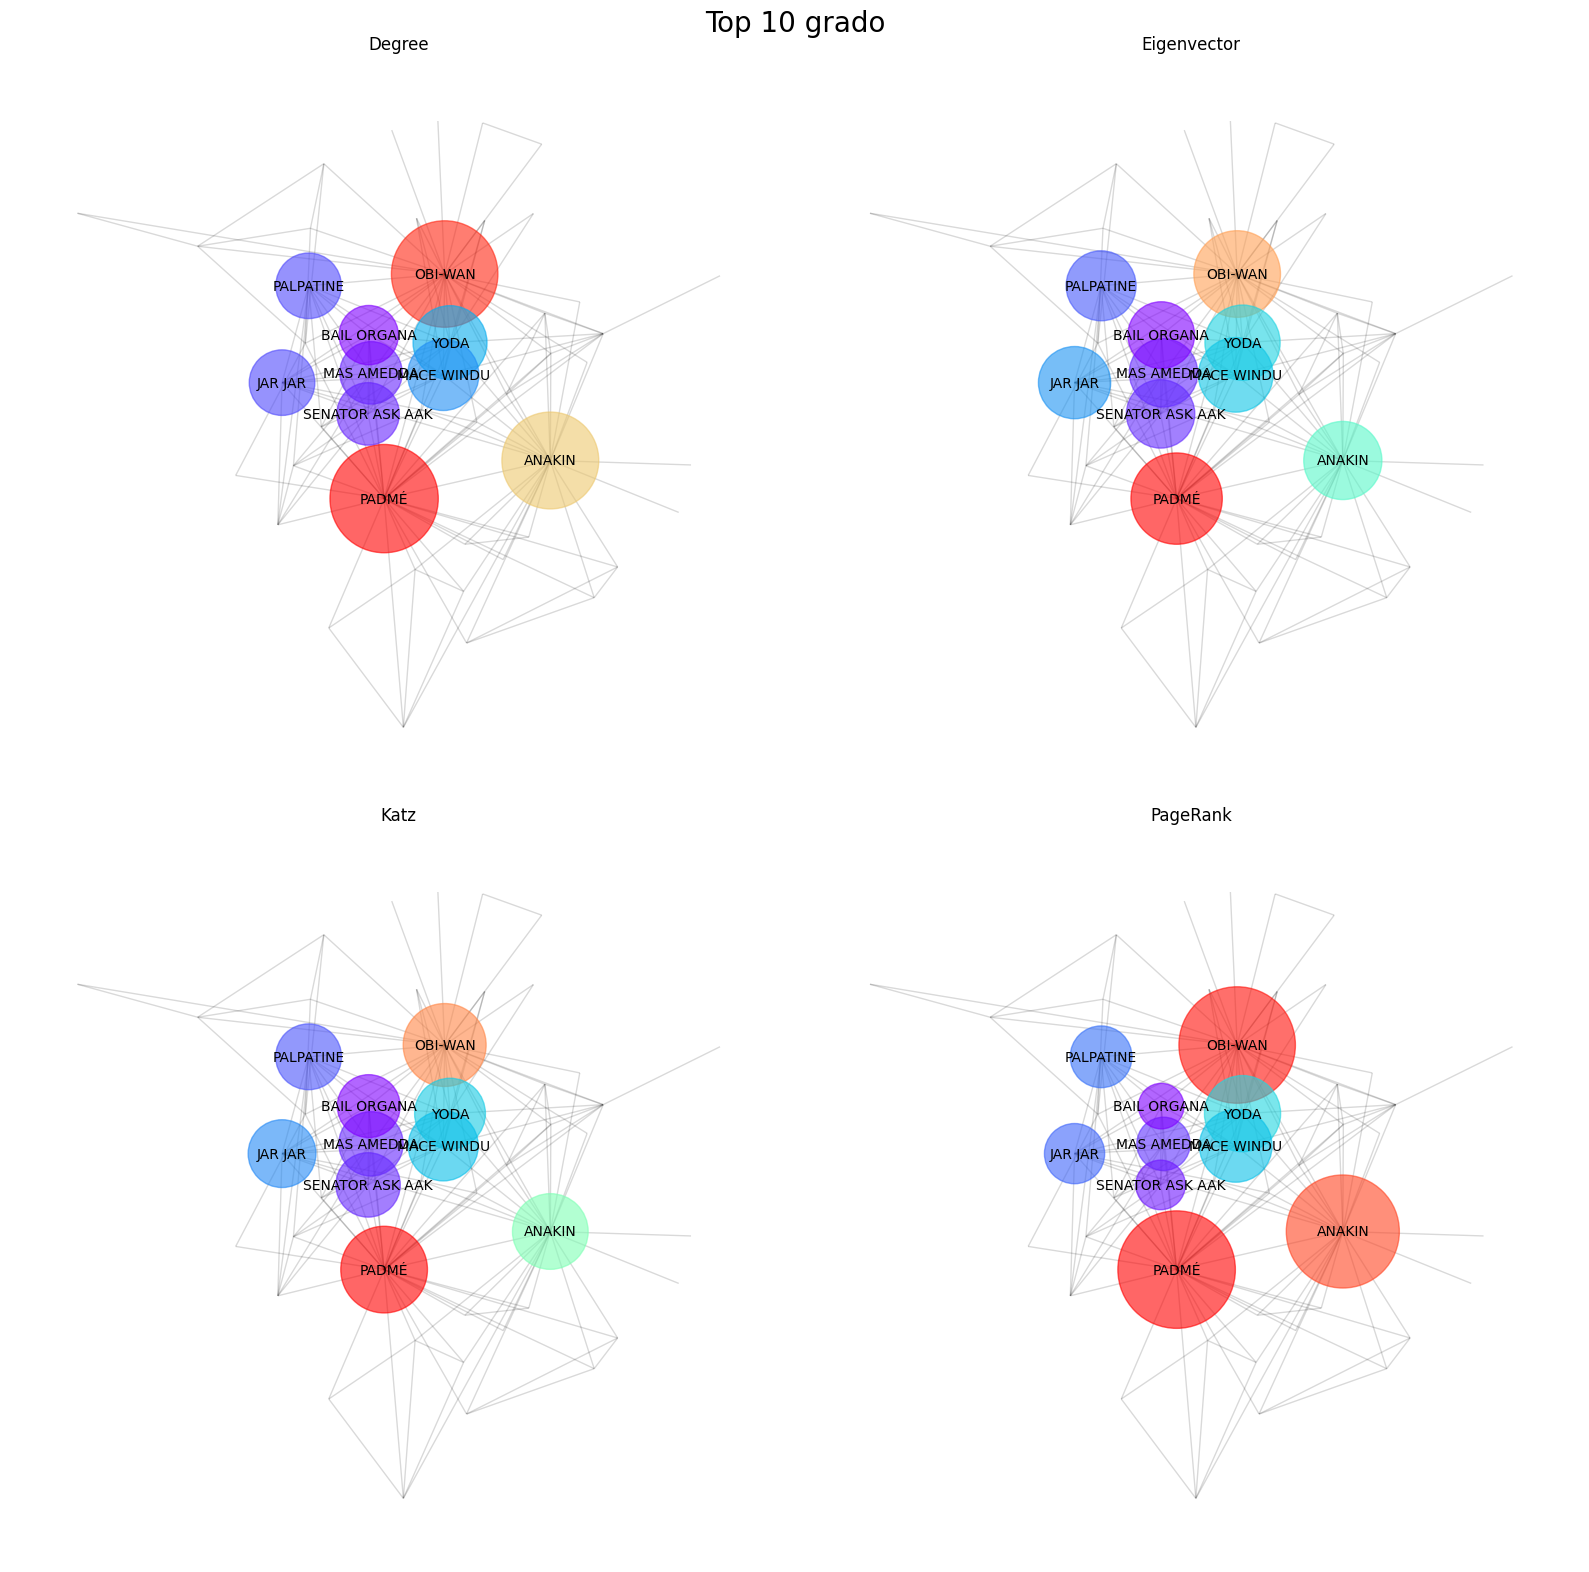

In [12]:
plot_centralidades(
    top_pos=top_deg, title='Top 10 grado', nodesize=60000)

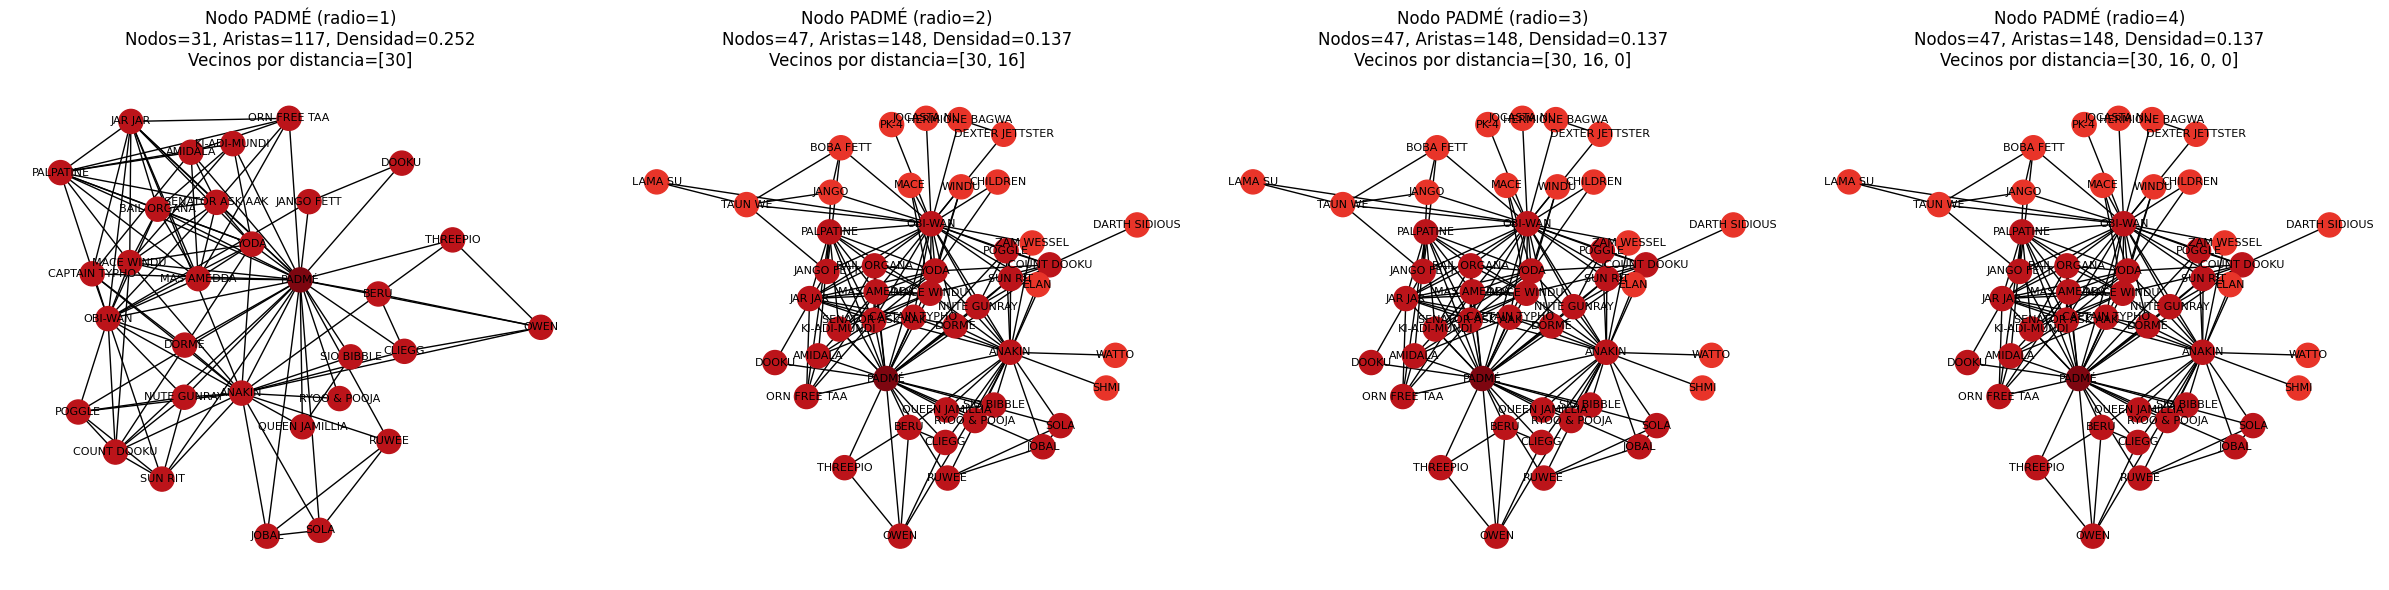

In [13]:
maxpos_node, maxpos_val = max(deg_centralidades.items(), key=lambda kv: kv[1])
plot_ego_radii_4panel(G1, maxpos_node, radii=(
    1, 2, 3, 4), layout="kamada_kawai")

## Top Eigenvector

In [14]:
df_top_eig = tabla(top_eig, digits=4)

,node,Degree,Eigenvector,Katz,PageRank
0,PADMÉ,0.1014,0.0721,0.0649,0.1193
1,OBI-WAN,0.0980,0.0649,0.0594,0.1172
2,ANAKIN,0.0811,0.0528,0.0495,0.1104
3,YODA,0.0473,0.0489,0.0433,0.0501
4,MACE WINDU,0.0439,0.0481,0.0424,0.0457
5,JAR JAR,0.0372,0.0451,0.0397,0.0313
6,PALPATINE,0.0372,0.0423,0.0375,0.0330
7,MAS AMEDDA,0.0338,0.0404,0.0359,0.0246
8,SENATOR ASK AAK,0.0338,0.0404,0.0359,0.0213
9,BAIL ORGANA,0.0304,0.0385,0.0342,0.0180


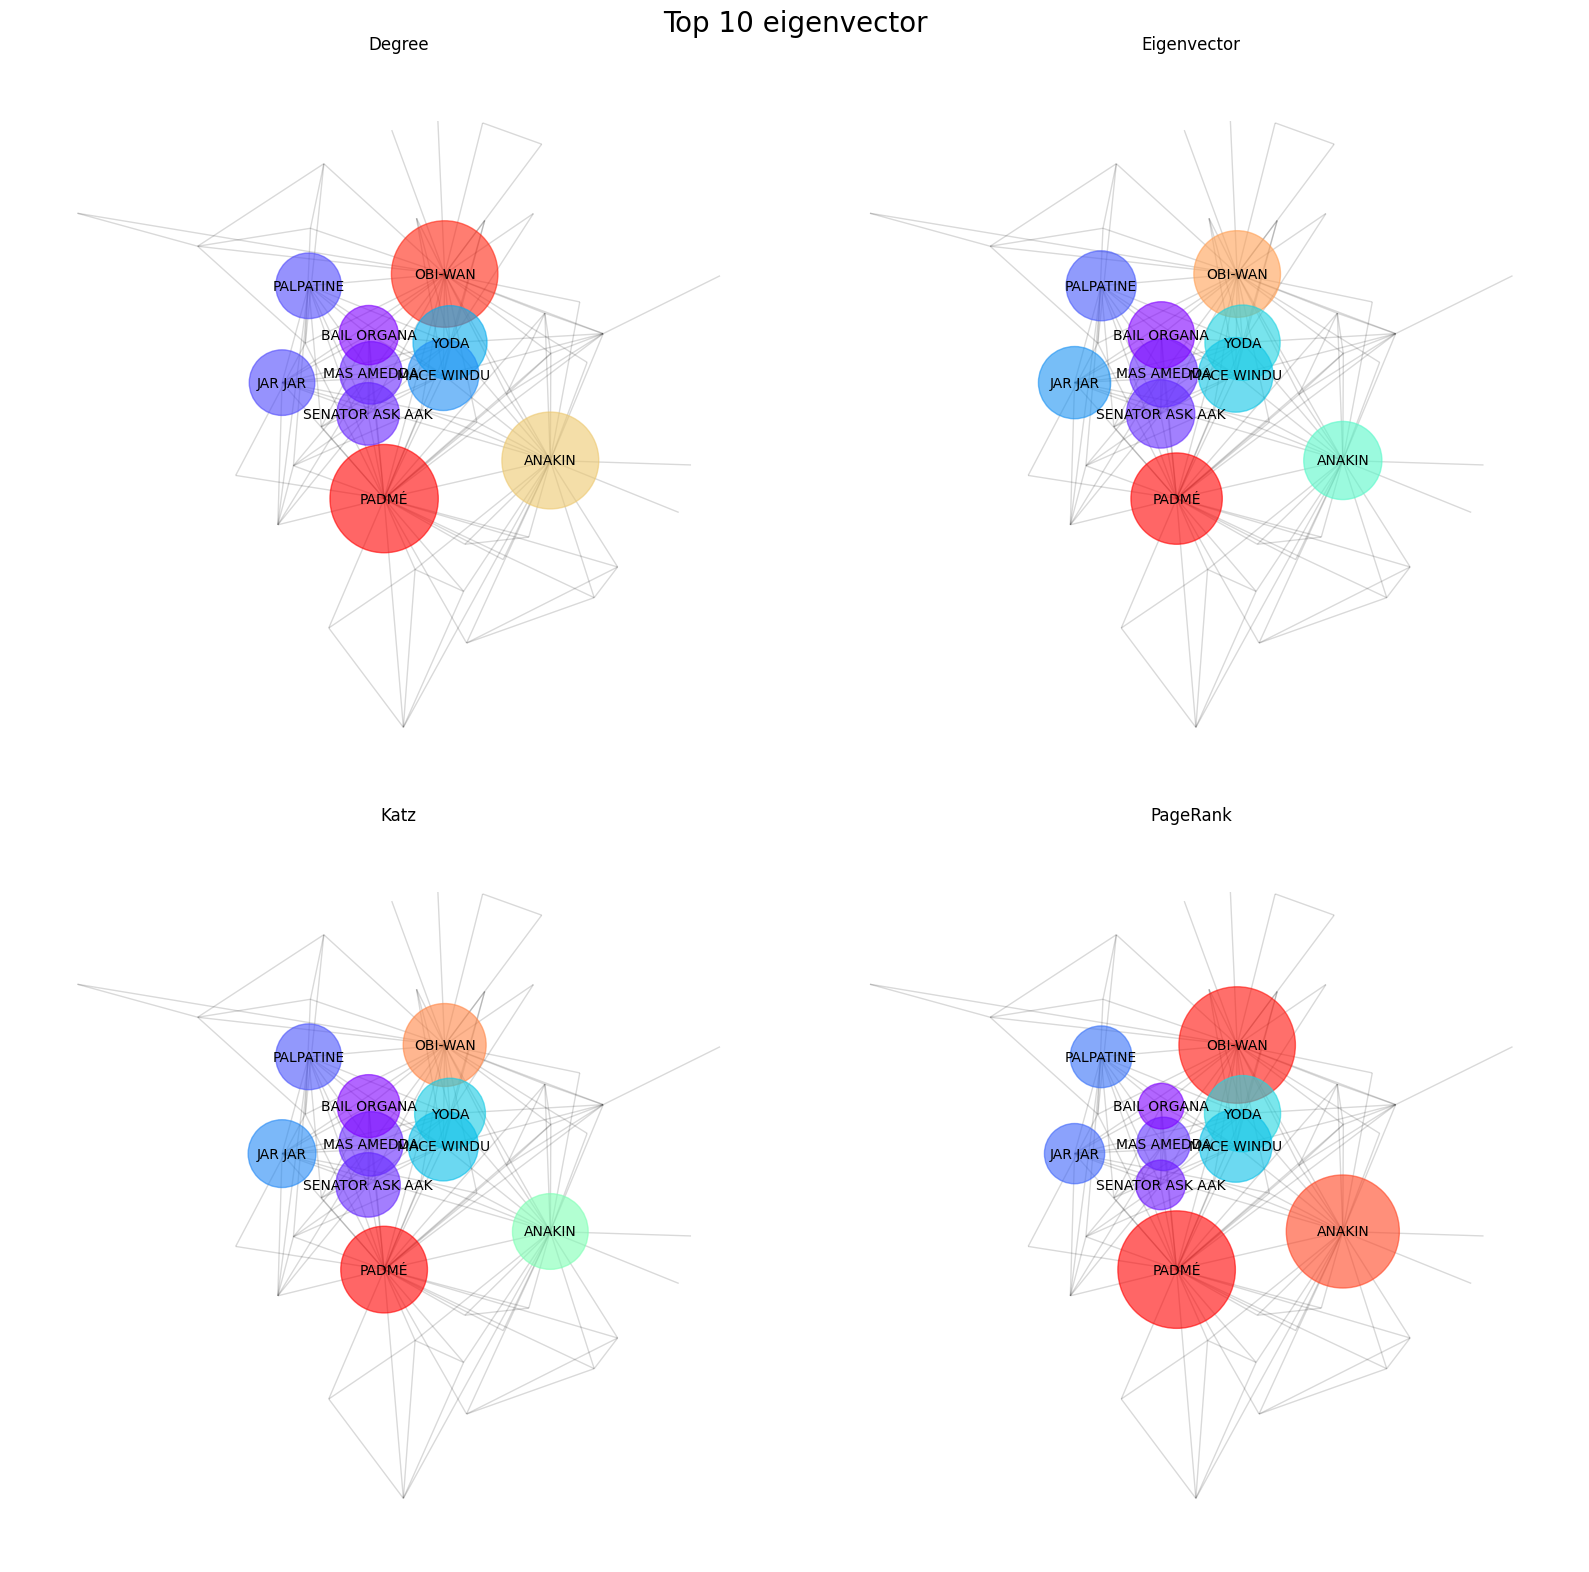

In [15]:
plot_centralidades(
    top_pos=top_eig, title='Top 10 eigenvector', nodesize=60000)

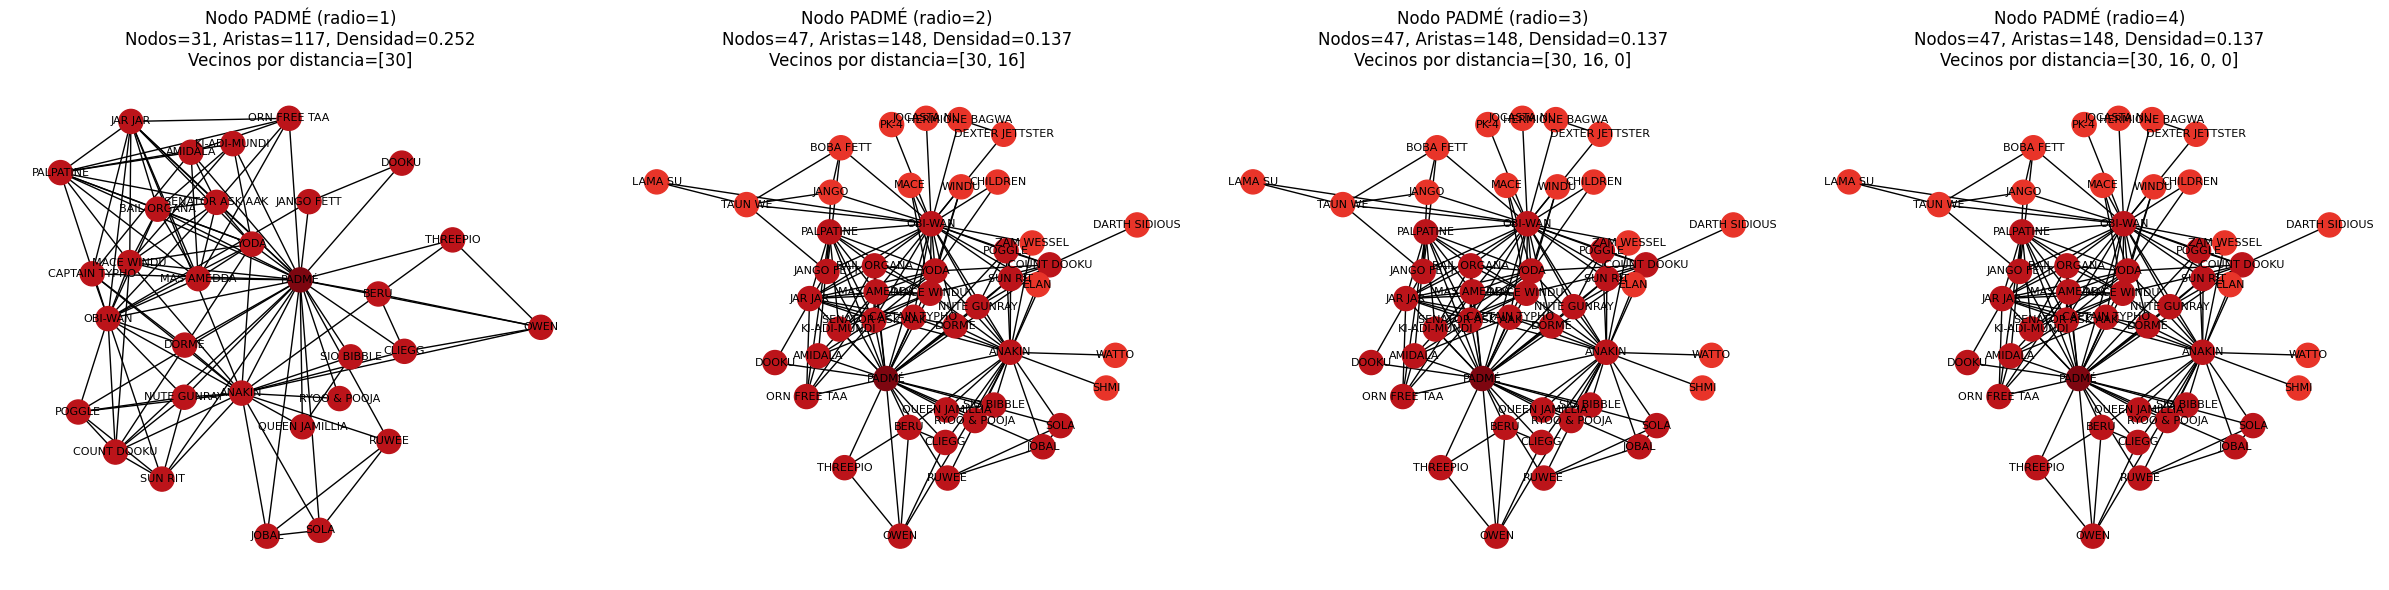

In [16]:
maxpos_node, maxpos_val = max(eig_centralidades.items(), key=lambda kv: kv[1])
plot_ego_radii_4panel(G1, maxpos_node, radii=(
    1, 2, 3, 4), layout="kamada_kawai")

## Top Katz

In [17]:
df_top_katz = tabla(top_katz, digits=4)

,node,Degree,Eigenvector,Katz,PageRank
0,PADMÉ,0.1014,0.0721,0.0649,0.1193
1,OBI-WAN,0.0980,0.0649,0.0594,0.1172
2,ANAKIN,0.0811,0.0528,0.0495,0.1104
3,YODA,0.0473,0.0489,0.0433,0.0501
4,MACE WINDU,0.0439,0.0481,0.0424,0.0457
5,JAR JAR,0.0372,0.0451,0.0397,0.0313
6,PALPATINE,0.0372,0.0423,0.0375,0.0330
7,MAS AMEDDA,0.0338,0.0404,0.0359,0.0246
8,SENATOR ASK AAK,0.0338,0.0404,0.0359,0.0213
9,BAIL ORGANA,0.0304,0.0385,0.0342,0.0180


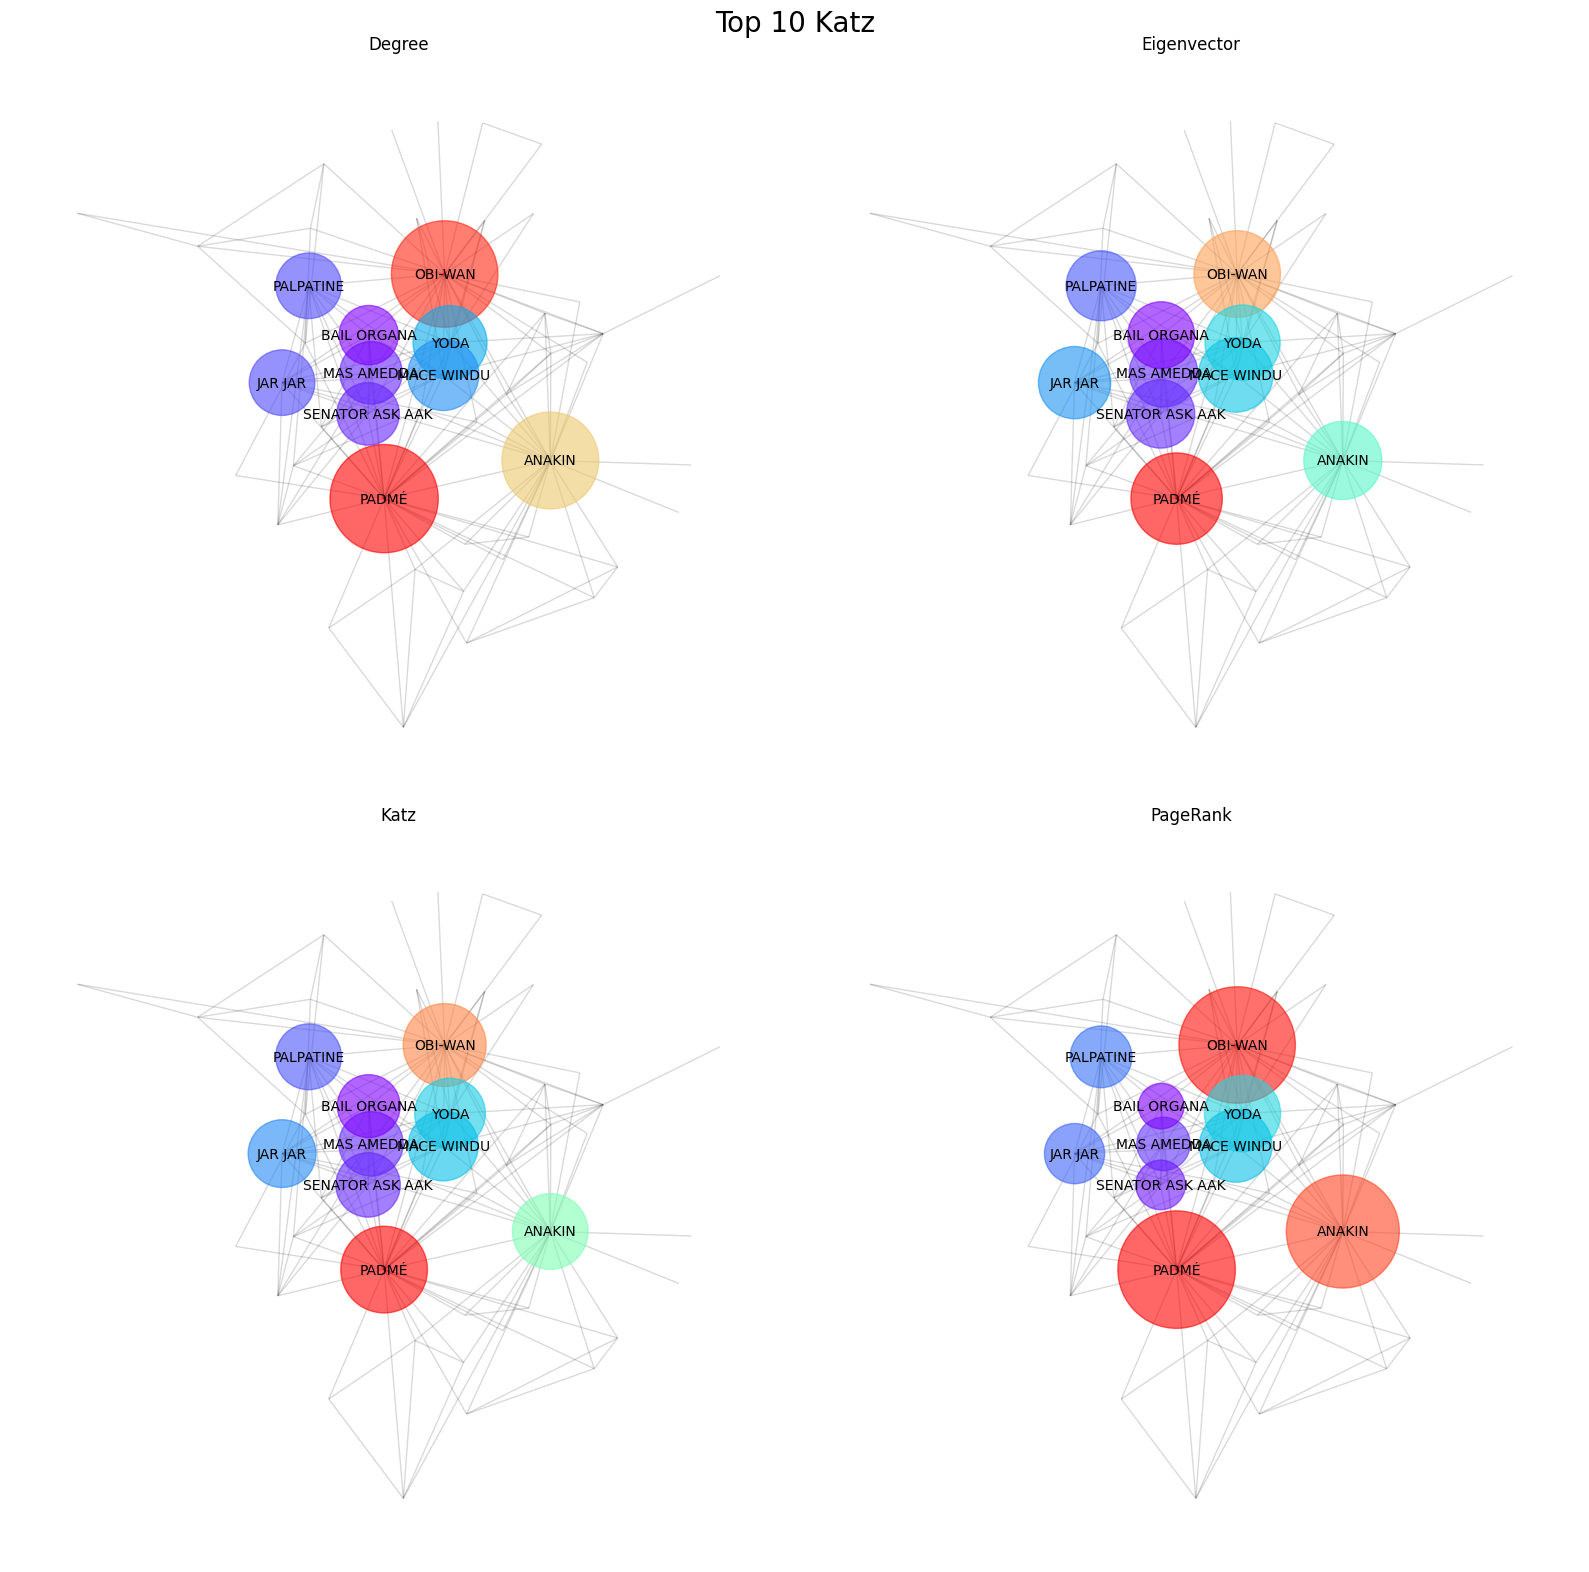

In [18]:
plot_centralidades(
    top_pos=top_katz, title='Top 10 Katz', nodesize=60000)

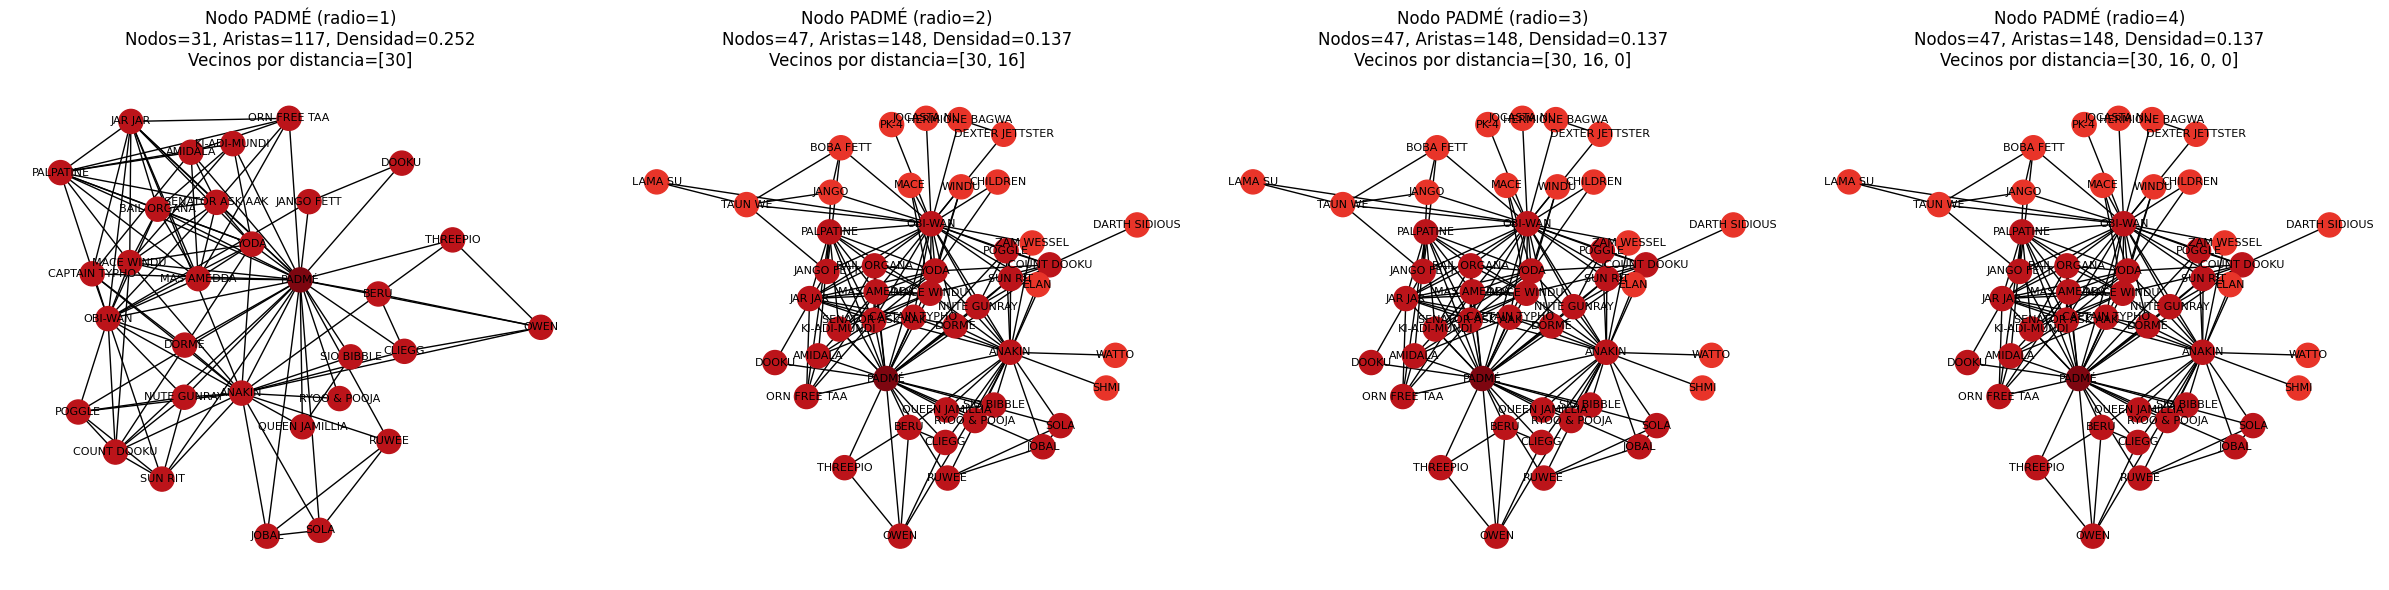

In [19]:
maxpos_node, maxpos_val = max(katz_centralidades.items(), key=lambda kv: kv[1])
plot_ego_radii_4panel(G1, maxpos_node, radii=(
    1, 2, 3, 4), layout="kamada_kawai")

## Top PageRank

In [20]:
df_top_pg = tabla(top_pg, digits=4)

,node,Degree,Eigenvector,Katz,PageRank
0,PADMÉ,0.1014,0.0721,0.0649,0.1193
1,OBI-WAN,0.0980,0.0649,0.0594,0.1172
2,ANAKIN,0.0811,0.0528,0.0495,0.1104
3,YODA,0.0473,0.0489,0.0433,0.0501
4,MACE WINDU,0.0439,0.0481,0.0424,0.0457
5,PALPATINE,0.0372,0.0423,0.0375,0.0330
6,JAR JAR,0.0372,0.0451,0.0397,0.0313
7,COUNT DOOKU,0.0304,0.0330,0.0308,0.0273
8,MAS AMEDDA,0.0338,0.0404,0.0359,0.0246
9,SENATOR ASK AAK,0.0338,0.0404,0.0359,0.0213


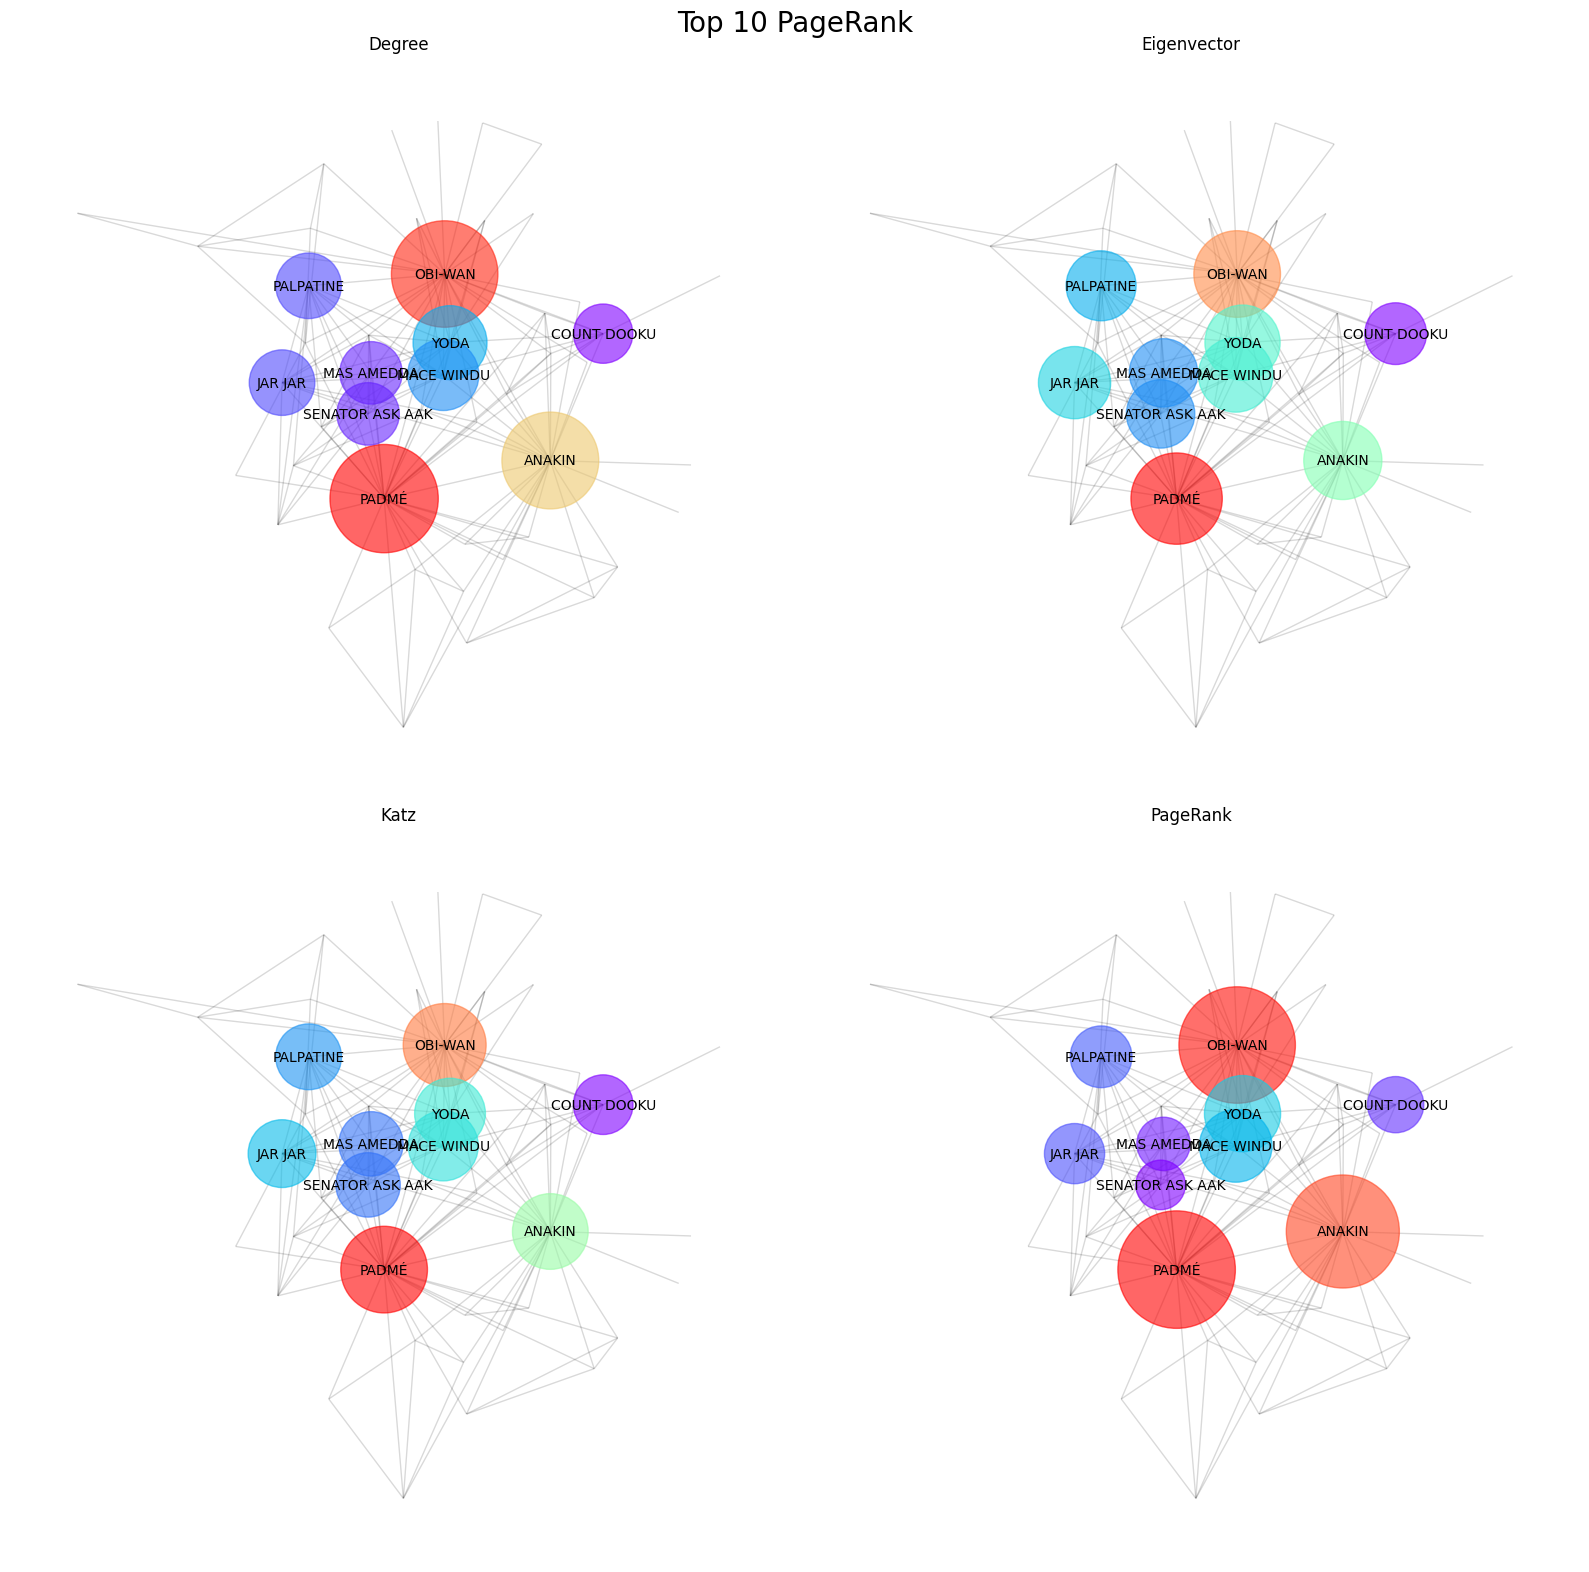

In [21]:
plot_centralidades(
    top_pos=top_pg, title='Top 10 PageRank', nodesize=60000)

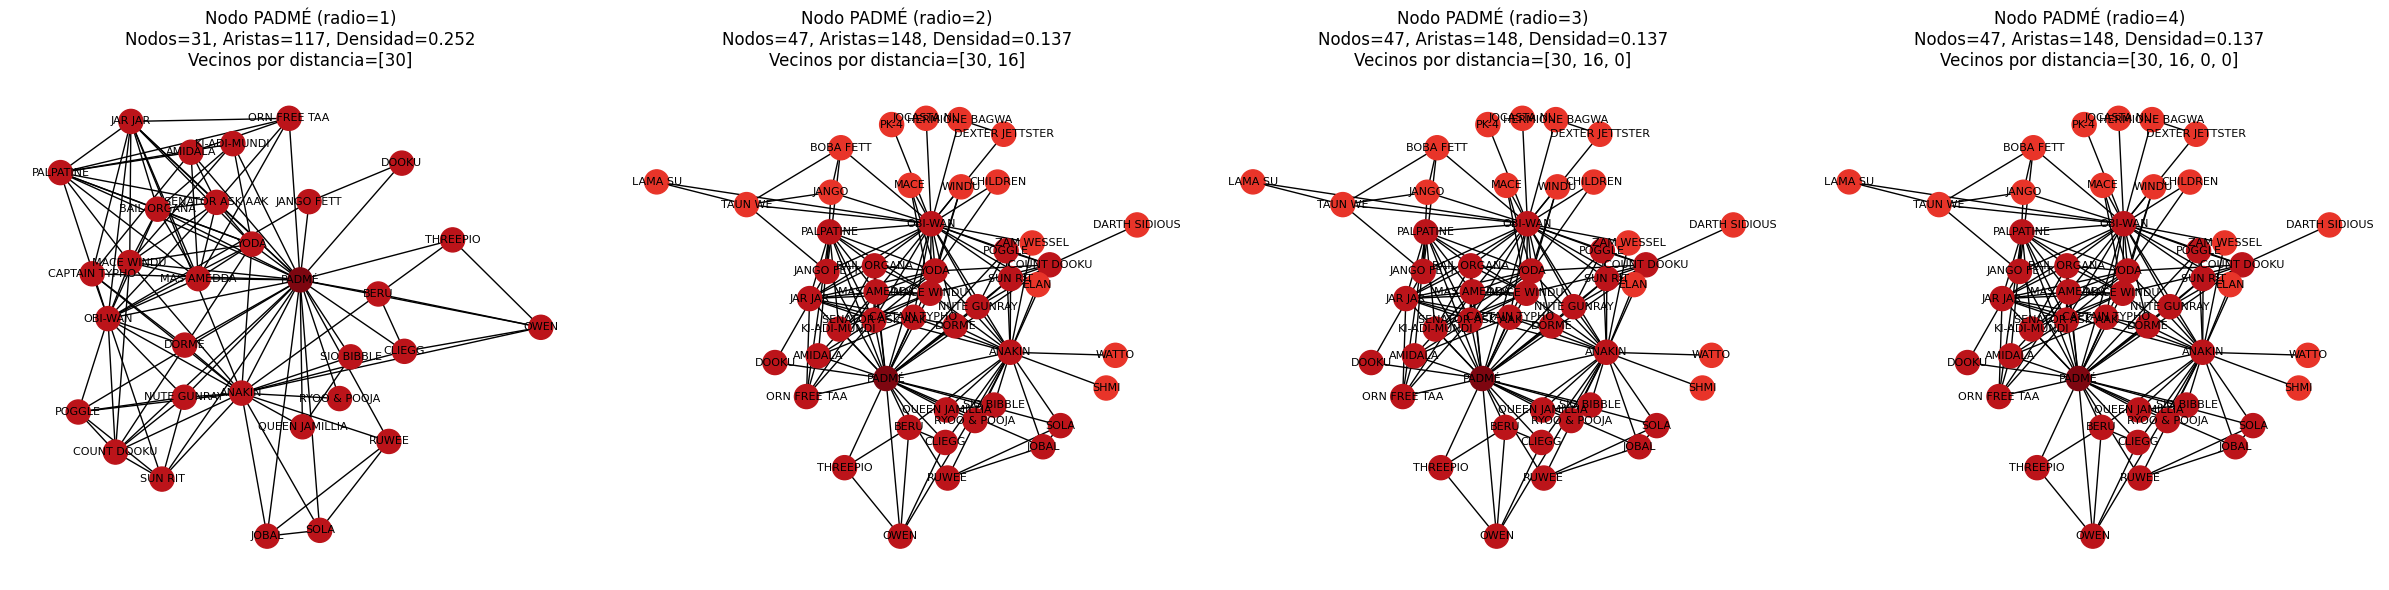

In [22]:
maxpos_node, maxpos_val = max(pg_centralidades.items(), key=lambda kv: kv[1])
plot_ego_radii_4panel(G1, maxpos_node, radii=(
    1, 2, 3, 4), layout="kamada_kawai")

# Interpretacion

Se interpretan las diferencias entre las centralidades de grado, eigenvector, Katz y PageRank. Se analizan los vértices que tienen una mayor diferencia entre estas centralidades y se discute su significado en el contexto de la red de colaboración. Se examinan los vecinos de estos vértices para entender cómo su posición en la red afecta su centralidad y cómo esto se relaciona con su papel como investigadores en la red.

Las cuatro métricas dan prácticamente el mismo top, solo cambia el orden en los puestos bajos y aparece Dooku en PageRank. Eso indica que la red está muy dominada por una misma narrativa, los personajes principales comparten muchas escenas y además comparten escenas con otros personajes también centrales.

PADMÉ, OBI-WAN y ANAKIN son el top en todo porque son los hubs narrativos de la película.
  
Eigenvector y Katz no cambian nada respecto a grado, los personajes más conectados ya están conectados entre sí, tener muchas conexiones y estar conectado al núcleo se vuelven casi lo mismo, 

YODA y MACE WINDU altos pero debajo del trío principal porque están en el consejo Jedi.
JAR JAR, PALPATINE, MAS AMEDDA, SENATOR ASK AAK, BAIL ORGANA forman el bloque político de Coruscant. Salen altos porque comparten escenas recurrentes entre ellos y con Padmé; o sea, su centralidad viene de estar “pegados” a un personaje central.

Que Katz solo haya convergido hasta $\alpha\approx 0.08$ dice algo sobre la “fuerza espectral” de la red (qué tan grande es su núcleo/densidad efectiva, y más aún si hay pesos altos). La red con conectividad suficientemente fuertes como para que Katz necesite atenuación alta; por tanto, Katz está midiendo sobre todo cercanía local al núcleo, no influencia global de caminos largos.

# Apendice: $\text{degree} - \text{eigenvector}$

Conseguimos las diferencias de $\text{degree} - \text{eigenvector}$, nos quedamos con las mas positivas, las mas negativas, las mas cercanas a 0 y las mas alejadas.



Padme es la que tiene mas coapariciones en la pelicula, y tambien la que tiene las coapariciones con personajes significativos (significativos es que sus vecinos tambien tienen coapariciones con otros)


**Los que tienen medida de centralidad de eigenvector mas grande tambien coinciden con la parte de la red que tiene mayor grado.**


Conseguimos las diferencias de $\text{degree} - \text{eigenvector}$, nos quedamos con las mas positivas, las mas negativas, las mas cercanas a 0 y las mas alejadas.


## Top positivos


Como es $\text{degree} - \text{eigenvector}$ son los que tienen muchos vecinos, pero sus vecinos no son muy importantes.

- Nodo tiene muchos vecinos
- Los vecinos tienen pocos vecinos

Contagian directamente a muchos, pero no se propaga mucho


**Obi-Wan esta conectado al 9% de la red, pero algunas de esas conexiones son con personajes que casi unicamente salen con el, como Lama Su.**


## Top Negativos


Como es $\text{degree} - \text{eigenvector}$ son los que tienen vecinos muy importantes y tienen pocos vecinos, o estan muy bien posicionados, pero no por tener muchos vecinos, sino porque los vecinos de los vecinos estan muy bien posicionados

Contagian directamente a pocos, pero se propaga mucho


**Bail Organa se conecta con muy pocos personajes, que, a comparacion de el, estan muy bien conectados en la red, como Obi-Wan y Padme**


## Top cercanos a 0


Los nodos que tienen la menor diferencia es porque es parecido cuanto pesan sus conexiones a la calidad de los nodos a los que estan conectados. Son parecidos a una red conexa, en una red conexa la diferencia de las centralidades ponderadas es 0

Justo en sus vecinos a radio = 1, se forma un $K_3$; mientras mas avanza el radio mas se va perdiendo la red completamente conexa, pero esa es la idea. En la red que estamos usando, este es el cluster mas parecido a una red completamente conexa, como un grupo de amigos que son muy amigos entre ellos.

Su densidad deberia ser la mas alta.


**Lama Su forma un $K_3$ con sus vecinos de radio 1, y sus vecinos de forman una subred mas densa que las otras 2 vistas. Se disipa rapidamente porque el diametro de la red era 4**


## Top alejados


Los que tienen la diferencia mas grande, es porque estan conectados a otros de los nodos mas importantes de la red y tienen pocas conexiones, JAJA como Hugo, que es amigo de Steve Jobs, Elon Musk y Bill Gates o no me acuerdo quien era el ultimo (Steve Jobs ya no); o son los nodos que tienen muchisimas conexiones y sus vecinos no.


**El que tiene mas diferencia de sus las coapariciones en las que aparece es Obi-Wan, es el que, en comparacion, sus coapariciones son menos significativas en relacion al total de sus coapariciones, porque sus vecinos casi no salen con mas**
